In [1]:
import polars as pl
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path

from jetutils.definitions import DATADIR, polars_to_xarray
from jetutils.data import standardize
from jetutils.derived_quantities import compute_norm_derivative
from jetutils.geospatial import gather_normal_da_jets, interp_jets_to_zero_one
from jetutils.geospatial import central_diff, detect_contours

basepath = Path(DATADIR, "exp8")

%load_ext IPython.extensions.autoreload
%autoreload 2
%matplotlib inline

In [ ]:
jets = pl.read_parquet(basepath.joinpath("all_jets_one_df.parquet")).cast({"time": pl.Datetime("ms")})

jets = jets.filter(
    (pl.col("is_polar").mean().over(["time", "jet ID"]) < 0.5)
    | (
        (pl.col("is_polar").mean().over(["time", "jet ID"]) > 0.5)
        & (pl.col("int").mode().first().over(["time", "jet ID"]) > 1.0e8)
    )
)

jets = jets.with_columns(
    **{
        "jet ID": (pl.col("is_polar").mean().over(["time", "jet ID"]) > 0.5).cast(
            pl.UInt32()
        )
    }
)

period: int = 15
offset = int(np.ceil(period / 2))

wind_sample = standardize(xr.open_dataset(basepath.joinpath("../ERA5/sample_high.nc")).isel(time=slice(100)))
da_pv = standardize(xr.open_dataset(basepath.joinpath("../ERA5/PV330_sample.nc"))).isel(time=slice(100))["pv"]
sigma = compute_norm_derivative(wind_sample, "s").rename("sigma")
interpd = gather_normal_da_jets(jets, sigma, dn=5e4, half_length=5e5, in_meters=True)
interpd = interp_jets_to_zero_one(
    interpd, ["sigma_interp", "is_polar"], n_interp=30
)
mapper = interpd["norm_index"].unique().sort().to_frame().with_row_index("indexer")
bias_correction = (
    interpd["time", "jet ID", "norm_index", "n", "sigma_interp"]
    .join(mapper, on="norm_index")
    .rolling("indexer", period=f"{period}i", offset=f"-{offset}i", group_by=("time", "jet ID", "n"))
    .agg(pl.col("sigma_interp").mean())
    .join(mapper, on="indexer")
    .drop("indexer")
)
bc = polars_to_xarray(bias_correction, ["time", "jet ID", "n", "norm_index"])
bc = detect_contours(bc, [0.], ("norm_index", "n"))
bc = bc.filter((pl.lit(0.).is_in(pl.col("norm_index").implode()) & pl.lit(1.).is_in(pl.col("norm_index").implode())).over("time", "jet ID", "contour"))
bc.drop("level", "cyclic").group_by("time", "jet ID", "norm_index").agg(pl.col("n").get(pl.col("n").abs().arg_min()))
# n_filtd = pl.col("n").filter(pl.col("zero") > 0) # funny
# bias_correction = (
#     interpd
#     ["time", "jet ID", "index", "n", "sigma_interp"]
#     .with_columns(zero=central_diff(pl.col("sigma_interp").rolling_mean_by("index", "25i").sign()).over(["time", "jet ID", "n"]).abs())
#     .group_by(["time", "jet ID", "index"], maintain_order=True).agg(n_max=n_filtd.get(n_filtd.abs().arg_min()))
#     .with_columns(pl.col("n_max").interpolate("nearest").fill_null(0.))
# )
# interpd = gather_normal_da_jets(jets, wind_sample["s"], dn=5e4, half_length=2e6 + bias_correction["n_max"].abs().max(), in_meters=True)
# interpd_bcd = interpd.join(bias_correction, on=["time", "jet ID", "index"]).with_columns(n=pl.col("n") - pl.col("n_max")).filter(pl.col("n").abs() <= 2e6).with_columns(side=pl.col("n").sign().cast(pl.Int32()))
# interpd_bcd = interp_jets_to_zero_one(interpd_bcd, ["s_interp"])
# interpd = interp_jets_to_zero_one(interpd, ["s_interp"]).filter(pl.col("n").abs() <= 2e6)

# polars_to_xarray(interpd_bcd, ["time", "jet ID", "norm_index", "n"]).mean("time")[1].T.plot()
# plt.axhline(0.)
# plt.figure()
# polars_to_xarray(interpd, ["time", "jet ID", "norm_index", "n"]).mean("time")[1].T.plot()
# plt.axhline(0.)

/Users/bandelol/Documents/code_local/jestex/jetutils/data.py:427: FutureWarning: Supplying chunks as dimension-order tuples is deprecated. It will raise an error in the future. Instead use a dict with dimension names as keys.
  da[var] = da[var].chunk(chunks)


In [63]:
cs.drop("level", "cyclic").group_by("time", "jet ID", "norm_index").agg(pl.col("n").get(pl.col("n").abs().arg_min()))

time,jet ID,norm_index,n
datetime[ms],u32,f64,f64
1959-01-06 12:00:00,0,0.766667,150000.0
1959-01-10 12:00:00,0,0.8,100000.0
1959-01-11 18:00:00,0,0.366667,0.0
1959-01-17 18:00:00,1,0.533333,100000.0
1959-01-02 00:00:00,1,0.366667,50000.0
…,…,…,…
1959-01-10 18:00:00,0,0.933333,150000.0
1959-01-18 18:00:00,1,0.8,100000.0
1959-01-23 18:00:00,1,0.1,50000.0


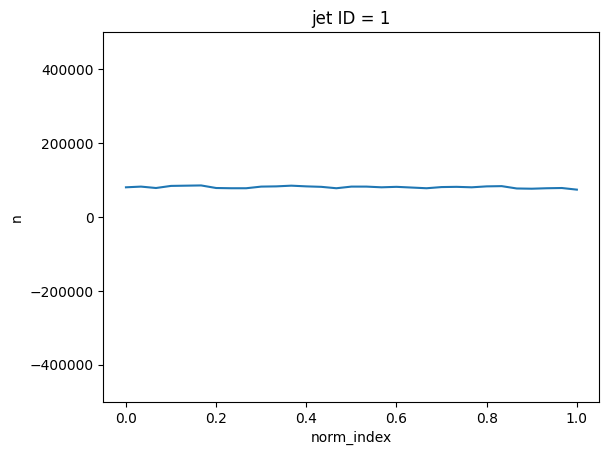

In [62]:
polars_to_xarray(cs.drop("level", "cyclic").group_by("time", "jet ID", "norm_index").agg(pl.col("n").get(pl.col("n").abs().arg_min())), ["time", "jet ID", "norm_index"]).mean("time")[1].plot(ylim=[-5e5, 5e5])

In [33]:
cs.filter(pl.lit([0., 30.]).is_in(pl.col("indexer").implode().implode()).all().over("time", "jet ID"))

time,jet ID,contour,level,cyclic,indexer,n
datetime[ms],u32,i64,f64,bool,f64,f64


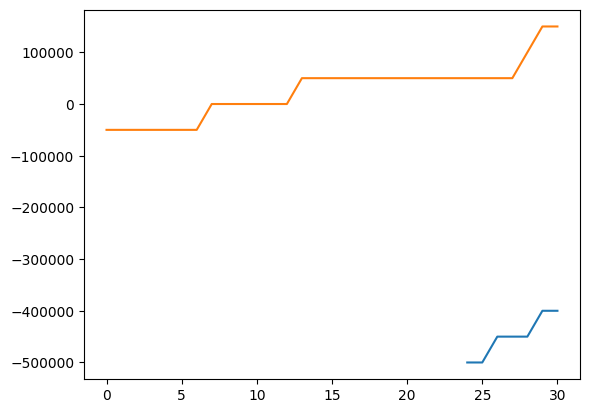

In [18]:
from jetutils.geospatial import detect_contours
cs = detect_contours(bc, [0.], ("indexer", "n"))
for idx, c in cs.group_by("time", "jet ID"):
    for ci, cc in c.group_by("contour"):
        plt.plot(cc["indexer"], cc["n"])
    break

In [ ]:
from jetutils.geospatial import central_diff
n_filtd = pl.col("n").filter(pl.col("zero") > 0) # funny
bias_correction = (
    interpd
    ["time", "jet ID", "index", "n", "sigma_interp"]
    .with_columns(zero=central_diff(pl.col("sigma_interp").rolling_mean_by("index", "25i").sign()).over(["time", "jet ID", "n"]).abs())
    .group_by(["time", "jet ID", "index"], maintain_order=True).agg(n_max=n_filtd.get(n_filtd.abs().arg_min()))
    .with_columns(pl.col("n_max").interpolate("nearest").fill_null(0.))
)

time,jet ID,index,n_max
datetime[ms],u32,i64,f64
1959-01-01 00:00:00,0,0,0.0
1959-01-01 00:00:00,0,1,400000.0
1959-01-01 00:00:00,0,2,400000.0
1959-01-01 00:00:00,0,3,350000.0
1959-01-01 00:00:00,0,4,350000.0
…,…,…,…
1959-01-25 18:00:00,1,108,-50000.0
1959-01-25 18:00:00,1,109,-50000.0
1959-01-25 18:00:00,1,110,-100000.0


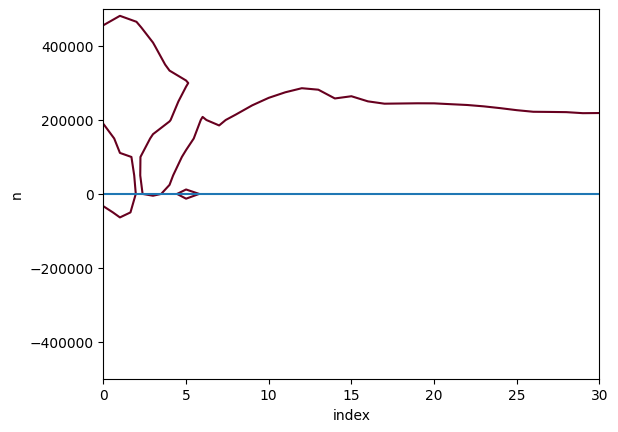

In [92]:
polars_to_xarray(
    interpd
    .filter(
        pl.col("time") == pl.col("time").unique().get(20), 
        pl.col("jet ID") == pl.col("jet ID").unique().get(0)
    )
    ["index", "n", "sigma_interp"]
    .with_columns(pl.col("sigma_interp").rolling_mean_by("index", "25i").over("n"))
    , ["index", "n"]
).T.plot.contour(levels=[0.])
plt.axhline(0)